In [1]:
#loading metacells of rna and atac data
import anndata as anndata
import pandas as pd
import numpy as np

sc_rna = anndata.read_h5ad("/home/fgsasse_lrs_1/Downloads/BA/BA_data/SEAcells/SEACell_summarized_RNA.h5ad")  
sc_atac = anndata.read_h5ad("/home/fgsasse_lrs_1/Downloads/BA/BA_data/SEAcells/SEACell_summarized_ATAC.h5ad")

gene_peaks_10kb = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/TSS windows/gene_peak_assignments_10kb.csv")
gene_peaks_20kb = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/TSS windows/gene_peak_assignments_20kb.csv")
gene_peaks_50kb = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/TSS windows/gene_peak_assignments_50kb.csv")
gene_peaks_100kb = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/TSS windows/gene_peak_assignments_100kb.csv")

In [2]:
sc_rna.obs_names.unique().size, sc_atac.obs_names.unique().size

(1260, 1260)

In [ ]:
#function for normalizing the aggregated data by total counts per SEACell to get relative accessibility/expression values (compositional normalization)
def compositional_normalize_adata(adata):
    import pandas as pd
    import scipy.sparse as sp
    
    # extract to dense DataFrame
    if sp.issparse(adata.X):
        df = pd.DataFrame(adata.X.toarray(), index=adata.obs_names, columns=adata.var_names)
    else:
        df = pd.DataFrame(adata.X, index=adata.obs_names, columns=adata.var_names)
    
    # normalize
    row_sums = df.sum(axis=1)
    if (row_sums == 0).any():
        print(f"Warning: {(row_sums == 0).sum()} metacells with zero counts.")
    df_norm = df.div(row_sums, axis=0)
    
    # put back into AnnData, preserving obs/var metadata
    adata_norm = adata.copy()
    adata_norm.X = df_norm.values
    return adata_norm

sc_rna_norm = compositional_normalize_adata(sc_rna)
sc_atac_norm = compositional_normalize_adata(sc_atac)

In [4]:
#Reindex the dataframes to ensure they are in the same order
sc_atac_norm = sc_atac_norm[sc_rna_norm.obs_names, :]
sc_rna_norm = sc_rna_norm[sc_atac_norm.obs_names, :]
print(sc_atac_norm.obs_names.equals(sc_rna_norm.obs_names))  # Should return True

sc_rna_norm.shape

True


(1260, 19380)

In [5]:
#Substract the genes that are present in the gene_peaks_10kb dataframe from the sc_rna_norm dataframe, to only keep the genes that have peaks assigned to them
genes_with_peaks_10kb = gene_peaks_10kb["gene_id"].tolist()
sc_rna_norm = sc_rna_norm[:, genes_with_peaks_10kb] 
print(sc_rna_norm.shape)

(1260, 19380)


In [ ]:
#taking the minimum non-zero value in the sc_rna_norm matrix to add it to all values before log transformation to avoid taking log of zero
import numpy as np
non_zero_mask = (sc_rna_norm.X > 0)
epsilon_rna = np.min(sc_rna_norm.X[non_zero_mask])

#taking the minimum non-zero value in the sc_atac_norm matrix to add it to all values before log transformation to avoid taking log of zero
non_zero_mask = (sc_atac_norm.X > 0)
epsilon_at= np.min(sc_atac_norm.X[non_zero_mask])

In [11]:
#log transformation (for norm. distribution) & scaling 10000000+1
#log scaling both datasets by multiplying by 10 million and adding 1 to avoid log(0) issues, then taking log10
sc_rna_norm.X = np.log10((sc_rna_norm.X+ epsilon_rna)*10000000) 
sc_atac_norm.X = np.log10((sc_atac_norm.X+ epsilon_at)*10000000)
print(sc_atac_norm.X)
print(sc_rna_norm.X)

/home/fgsasse_lrs_1/miniforge3/envs/seacells/lib/python3.12/site-packages/anndata/_core/anndata.py:639: FutureWarning: Setting element `.X` of view of `AnnData` object will obey copy-on-write semantics in the next minor release. 
  if self._handle_view_X_cow(value):
/tmp/ipykernel_3360547/3560636608.py:3: ImplicitModificationWarning: Modifying `X` on a view results in data being overridden
  sc_rna_norm.X = np.log10((sc_rna_norm.X+ epsilon_rna)*10000000)
/tmp/ipykernel_3360547/3560636608.py:4: ImplicitModificationWarning: Modifying `X` on a view results in data being overridden
  sc_atac_norm.X = np.log10((sc_atac_norm.X+ epsilon_at)*10000000)


[[0.43982004 1.69799888 0.43982004 ... 0.43982004 2.41558842 2.40686762]
 [0.43982004 1.47127901 0.43982004 ... 1.47127901 2.35577031 2.34484141]
 [0.43982004 0.43982004 1.49829121 ... 1.59463765 2.32757396 2.31616369]
 ...
 [0.43982004 0.43982004 1.59292122 ... 0.43982004 2.41923129 2.41605872]
 [1.45398172 0.43982004 1.71087766 ... 0.43982004 2.35715898 2.35427201]
 [0.43982004 1.67205925 0.43982004 ... 0.43982004 2.39624422 2.39516554]]
[[3.4748828  2.70166939 1.93225017 ... 2.70166939 2.53491418 3.28408211]
 [3.41493749 2.79367345 2.64107722 ... 1.93225017 3.01701661 3.17291163]
 [3.4038261  2.93383761 1.93225017 ... 2.55713542 1.93225017 3.21293761]
 ...
 [3.54541423 3.11222931 1.93225017 ... 1.93225017 1.93225017 3.38422967]
 [3.47596518 3.04327385 1.93225017 ... 1.93225017 2.92368264 3.30750865]
 [3.58442372 1.93225017 1.93225017 ... 1.93225017 1.93225017 3.39563446]]


In [12]:
gene_peaks_100kb[0:10]

,gene_id,assigned_peaks
0,rpl24,"['1-32-526', '1-2372-3057', '1-3427-4032', '1-..."
1,cep97,"['1-32-526', '1-2372-3057', '1-3427-4032', '1-..."
2,nfkbiz,"['1-32-526', '1-2372-3057', '1-3427-4032', '1-..."
3,eed,"['1-32-526', '1-2372-3057', '1-3427-4032', '1-..."
4,hikeshi,"['1-32-526', '1-2372-3057', '1-3427-4032', '1-..."
5,tmem39a,"['1-32-526', '1-2372-3057', '1-3427-4032', '1-..."
6,ildr1a,"['1-32-526', '1-2372-3057', '1-3427-4032', '1-..."
7,gpa33a,"['1-32-526', '1-2372-3057', '1-3427-4032', '1-..."
8,f7l,"['1-11007-12962', '1-13276-13705', '1-14059-14..."
9,f7,"['1-21199-21555', '1-21590-23611', '1-27097-29..."


## Normal OLS on all windows

In [13]:
#check the maximum number of peaks assigned to each gene in all windows
import ast  
gene_peaks_10kb["num_assigned_peaks"] = gene_peaks_10kb["assigned_peaks"].apply(lambda x: len(ast.literal_eval(x)) if pd.notnull(x) else 0)
gene_peaks_20kb["num_assigned_peaks"] = gene_peaks_20kb["assigned_peaks"].apply(lambda x: len(ast.literal_eval(x)) if pd.notnull(x) else 0)
gene_peaks_50kb["num_assigned_peaks"] = gene_peaks_50kb["assigned_peaks"].apply(lambda x: len(ast.literal_eval(x)) if pd.notnull(x) else 0)
gene_peaks_100kb["num_assigned_peaks"] = gene_peaks_100kb["assigned_peaks"].apply(lambda x: len(ast.literal_eval(x)) if pd.notnull(x) else 0)
print(gene_peaks_10kb[["gene_id", "num_assigned_peaks"]].max())
print(gene_peaks_20kb[["gene_id", "num_assigned_peaks"]].max())
print(gene_peaks_50kb[["gene_id", "num_assigned_peaks"]].max())
print(gene_peaks_100kb[["gene_id", "num_assigned_peaks"]].max())

#number of samples in the pseudobulk datasets
print(sc_rna_norm.n_obs)
print(sc_atac_norm.n_obs)

gene_id               zzz3
num_assigned_peaks      17
dtype: object
gene_id               zzz3
num_assigned_peaks      32
dtype: object
gene_id               zzz3
num_assigned_peaks      69
dtype: object
gene_id               zzz3
num_assigned_peaks     125
dtype: object
1260
1260


In [14]:
#computing OLS regression for all windows by loading the function from the src folder 
from pathlib import Path
import sys

src_path = Path("/home/fgsasse_lrs_1/Downloads/BA/src/")

if str(src_path) not in sys.path:
       sys.path.insert(0, str(src_path)),

#import several functions from the src folder to classify peak-gene pairs and aggregate results
from your_package.ols import (
    compute_peak_gene_ols,
    classify_peak_gene_pairs,
    aggregate_peak_gene_categories)

ols_results = {}
ols_dfs = {}
agg_ols_dfs = {}

gene_peak_dict = {
    "10kb": gene_peaks_10kb,
    "20kb": gene_peaks_20kb,
    "50kb": gene_peaks_50kb,
    "100kb": gene_peaks_100kb,
}

window_label = ["10kb", "20kb", "50kb", "100kb"]

for window in window_label:

    print(f"Computing OLS regression for {window} window...")

    ols_results[window], ols_dfs[window] = compute_peak_gene_ols(
        rna_data=sc_rna_norm,
        atac_data=sc_atac_norm,
        gene_peaks_df=gene_peak_dict[window],
        window_label=window,
    )

    ols_dfs[window] = classify_peak_gene_pairs(
        ols_dfs[window]
    )

    agg_ols_dfs[window] = aggregate_peak_gene_categories(
        ols_dfs[window]
    )

agg_ols_dfs[window].head()

Computing OLS regression for 10kb window...
[10kb] OLS complete — 19380 genes processed
OLS DataFrame: 172,031 peak–gene pairs
Computing OLS regression for 20kb window...
[20kb] OLS complete — 19380 genes processed
OLS DataFrame: 360,392 peak–gene pairs
Computing OLS regression for 50kb window...
[50kb] OLS complete — 19380 genes processed
OLS DataFrame: 922,788 peak–gene pairs
Computing OLS regression for 100kb window...
[100kb] OLS complete — 19380 genes processed
OLS DataFrame: 1,853,805 peak–gene pairs


,window,gene,category,count
0,100kb,a1cf,non-significant,91
1,100kb,a1cf,sig. positive,4
2,100kb,a2ml,non-significant,74
3,100kb,a2ml,sig. positive,3
4,100kb,aaas,non-significant,98


,window,gene,peak,coef,pval,category
0,10kb,rpl24,1-2372-3057,-0.002342,0.253328,non-significant
1,10kb,rpl24,1-3427-4032,-0.003700,0.075140,non-significant
2,10kb,rpl24,1-4469-7268,-0.000331,0.873974,non-significant
3,10kb,rpl24,1-9541-9969,0.000190,0.928391,non-significant
4,10kb,rpl24,1-11007-12962,0.009300,0.000047,sig. positive


In [16]:
#summarize all OLS results (all_ols_dfs) into a single dataframe for easier comparison across windows
all_ols_dfs = pd.concat(ols_dfs.values(), ignore_index=True)
all_ols_dfs["window"].unique()

#save the all_ols_dfs dataframe to a csv file for downstream analysis and visualization
all_ols_dfs.to_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/OLS/Results/ols_res_all_windows_df_sc.csv", index=False)

## Plotting the OLS results

In [17]:
#read in the saved all_ols_dfs dataframe to confirm it was saved correctly
ols_all_df = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/OLS/Results/ols_res_all_windows_df_sc.csv")
ols_all_df.head()

#aggregate the number of significant peaks per gene and category  
agg_ols_all_df = (
    ols_all_df
    .dropna(subset=["pval", "coef", "category"])
    .groupby(["window", "gene", "category"]) 
    .size()
    .reset_index(name="count")
)

In [18]:
agg_ols_all_df.head()

,window,gene,category,count
0,100kb,a1cf,non-significant,91
1,100kb,a1cf,sig. positive,4
2,100kb,a2ml,non-significant,74
3,100kb,a2ml,sig. positive,3
4,100kb,aaas,non-significant,98


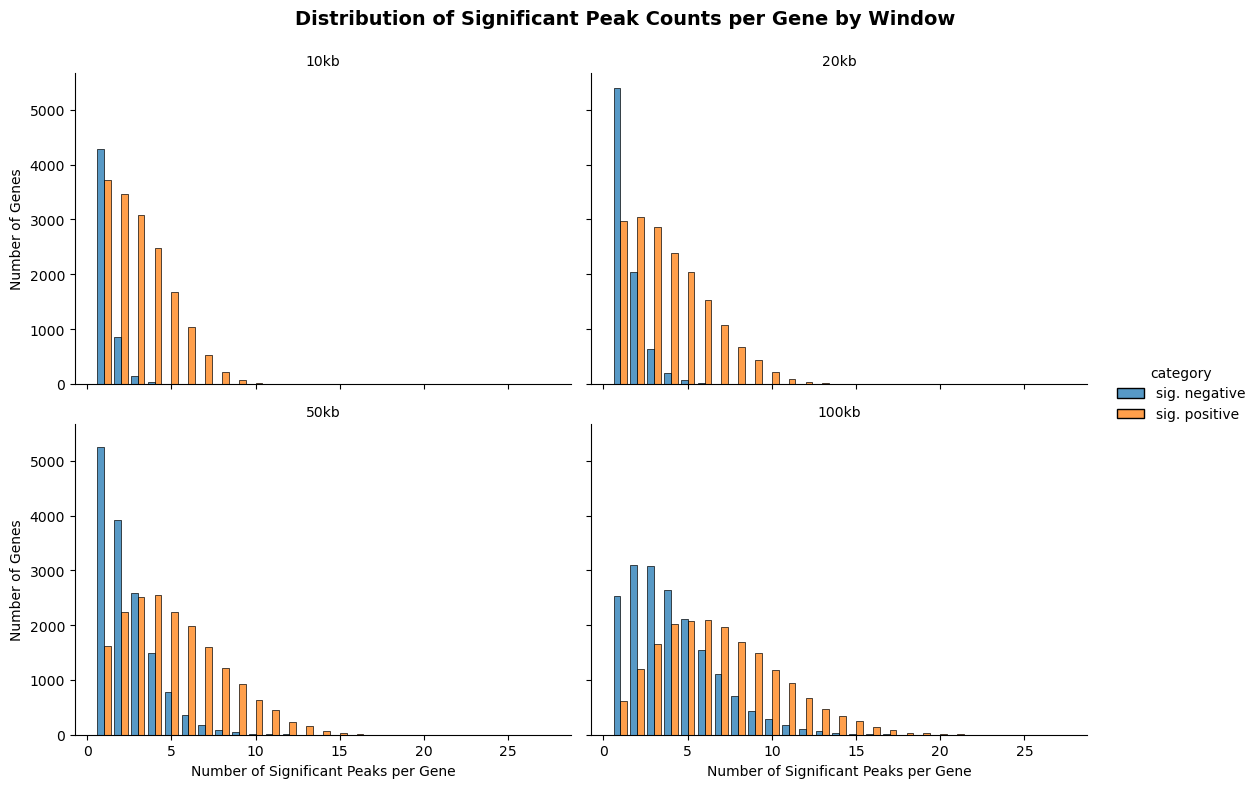

In [19]:
# plot the significant peak counts across all genes for the all windows using seaborn histplot, with separate colors for sig. positive and sig. negative categories
import matplotlib.pyplot as plt
import seaborn as sns

category_order = ["sig. negative", "sig. positive"]
agg_ols_all_df_non = agg_ols_all_df[agg_ols_all_df["category"] != "non-significant"]

plot = sns.displot(
    data=agg_ols_all_df_non,
    x="count",
    hue="category",
    hue_order=category_order,
    col="window",
    col_order=["10kb", "20kb", "50kb", "100kb"],
    col_wrap=2,          # <- 2 columns => 2x2 layout
    multiple="dodge",
    discrete=True,
    shrink=0.8,
    height=4,
    aspect=1.4,
)

plot.set_axis_labels(
    "Number of Significant Peaks per Gene",
    "Number of Genes",
)

plot.set_titles("{col_name}")

plot.figure.suptitle(
    "Distribution of Significant Peak Counts per Gene by Window",
    fontsize=14,
    fontweight="bold",
)

plot.figure.subplots_adjust(top=0.90)

plt.show()

## Deduplication across windows

In [2]:
#read in the saved all_ols_dfs dataframe to confirm it was saved correctly
import pandas as pd
ols_all_df = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/OLS/Results/ols_res_all_windows_df_sc.csv")
print(ols_all_df.head())

#make window categorical and ordered
ols_all_df["window"] = pd.Categorical(
    ols_all_df["window"],
    categories=["10kb", "20kb", "50kb", "100kb"],
    ordered=True
)

# Order by window
ols_all_df = ols_all_df.sort_values("window",ascending=True)
print(ols_all_df[["window", "gene", "peak", "coef", "pval", "category"]].head())

#"Dedublication" of gene-peak pairs by keeping only the first occurrence of each pair across all windows (since they are ordered by window size, this will keep the pair with the smallest window size)"
pair_summary = (
    ols_all_df
    .groupby(["gene", "peak"], as_index=False)
    .first()
)

#Sort by window to keep the smallest window size for each gene-peak pair
pair_summary = pair_summary.sort_values("window", ascending=True)
print(pair_summary[["window", "gene", "peak", "coef", "pval", "category"]].head())

#Sanity check to confirm that each gene-peak pair is now unique
pair_counts = pair_summary.groupby(["gene", "peak"]).size().reset_index(name="count")
print(pair_counts['count'].value_counts()) # Should show that all pairs have a count of 1

#Counts how many unique gene-peak pairs fall into each category for each window size
summary_counts = (pair_summary.groupby(["window", "gene", "category"]).size().reset_index(name="count"))
summary_counts.head()

  window   gene           peak      coef      pval         category
0   10kb  rpl24    1-2372-3057 -0.002342  0.253328  non-significant
1   10kb  rpl24    1-3427-4032 -0.003700  0.075140  non-significant
2   10kb  rpl24    1-4469-7268 -0.000331  0.873974  non-significant
3   10kb  rpl24    1-9541-9969  0.000190  0.928391  non-significant
4   10kb  rpl24  1-11007-12962  0.009300  0.000047    sig. positive
       window        gene                  peak      coef      pval  \
0        10kb       rpl24           1-2372-3057 -0.002342  0.253328   
114683   10kb  tmem176l.2  16-46651119-46651504  0.004019  0.451271   
114684   10kb  tmem176l.2  16-46654497-46655291  0.000035  0.994805   
114685   10kb  tmem176l.4  16-46654497-46655291 -0.006243  0.346896   
114686   10kb  tmem176l.4  16-46655794-46656156  0.008986  0.168194   

               category  
0       non-significant  
114683  non-significant  
114684  non-significant  
114685  non-significant  
114686  non-significant  
        w

/tmp/ipykernel_3653862/3872737723.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_counts = (pair_summary.groupby(["window", "gene", "category"]).size().reset_index(name="count"))


,window,gene,category,count
0,10kb,a1cf,non-significant,10
1,10kb,a1cf,sig. negative,0
2,10kb,a1cf,sig. positive,1
3,10kb,a2ml,non-significant,10
4,10kb,a2ml,sig. negative,0


/tmp/ipykernel_3653862/1019277128.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([window_labels[t.get_text()] for t in ax.get_xticklabels()])


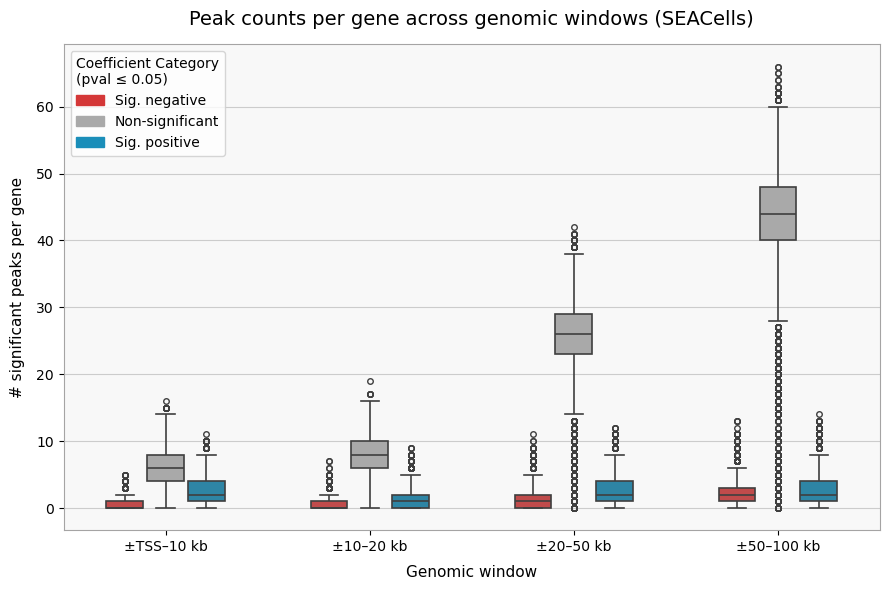

In [4]:
#Boxplot of the counts of peaks per gene (first occurrence of gene-peak pair across all windows) for each category and window size
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

category_order  = ["sig. negative", "non-significant", "sig. positive"]
category_colors = {
    "sig. negative":   "#D43737",
    "sig. positive":   "#1A8EB9",
    "non-significant": "#A9A9A9",
}

fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor("white")
ax.set_facecolor("#F8F8F8")

sns.boxplot(
    data=summary_counts,
    x="window", y="count", hue="category",
    hue_order=category_order,
    palette=category_colors,
    width=0.6,
    linewidth=1.2,
    fill=True,
    flierprops=dict(marker="o", markersize=4, linewidth=0),
    boxprops=dict(alpha=1),
    gap=0.1,
    ax=ax,
)

# Replace x-axis tick labels
window_labels = {
    "10kb":  "±TSS–10 kb",
    "20kb":  "±10–20 kb",
    "50kb":  "±20–50 kb",
    "100kb": "±50–100 kb",
}
ax.set_xticklabels([window_labels[t.get_text()] for t in ax.get_xticklabels()])

# Recolor fliers manually to match their box color
for line, color in zip(
    [c for c in ax.get_lines() if c.get_linestyle() == "none"],
    [category_colors[cat]
     for _ in summary_counts["window"].cat.categories
     for cat in category_order]
):
    line.set_markerfacecolor(color)
    line.set_markeredgecolor(color)
    line.set_alpha(0.7)

ax.set_title("Peak counts per gene across genomic windows (SEACells)",
             fontsize=14, fontweight="500", pad=14, loc="center")
ax.set_xlabel("Genomic window", fontsize=11, labelpad=8)
ax.set_ylabel("# significant peaks per gene", fontsize=11, labelpad=8)

ax.yaxis.grid(True, color="#cccccc", linewidth=0.8, linestyle="-", zorder=0)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_color("#a5a4a4")

handles = [mpatches.Patch(color=category_colors[c], alpha=1, label=c.capitalize())
           for c in category_order]
ax.legend(
    handles=handles,
    title="Coefficient Category\n(pval ≤ 0.05)",
    frameon=True,
    fontsize=10,
    loc="upper left",
    title_fontsize=10,
)

plt.tight_layout()
plt.show()

/tmp/ipykernel_3653862/1234671188.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([window_labels[t.get_text()] for t in ax.get_xticklabels()])


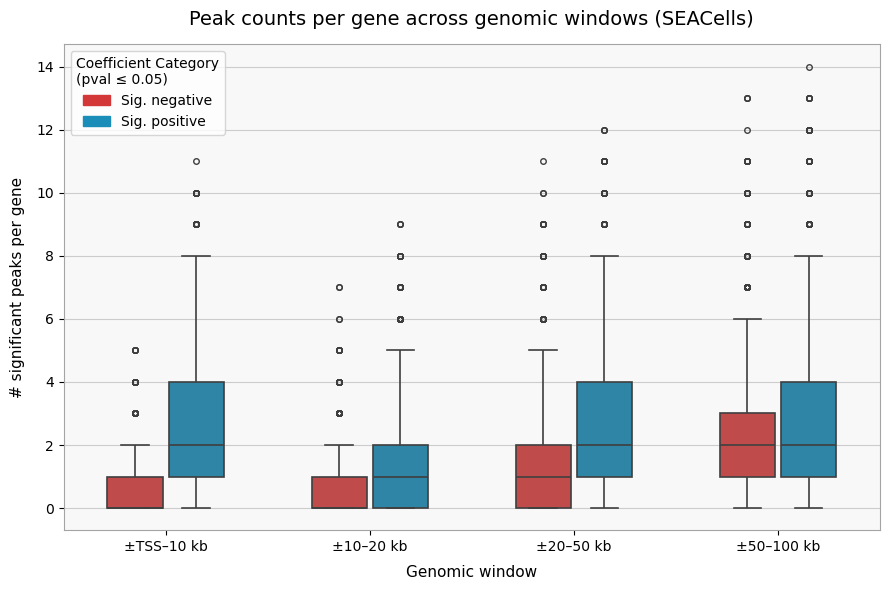

In [5]:
# Boxplot of the counts of peaks per gene (first occurrence of gene-peak pair across all windows) for significant categories only (non-significant category excluded) for each window size
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

category_order  = ["sig. negative", "sig. positive"]
category_colors = {
    "sig. negative":   "#D43737",
    "sig. positive":   "#1A8EB9",
}

only_sig = summary_counts[summary_counts["category"] != "non-significant"]

fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor("white")
ax.set_facecolor("#F8F8F8")

sns.boxplot(
    data=only_sig,
    x="window", y="count", hue="category",
    hue_order=category_order,
    palette=category_colors,
    width=0.6,
    linewidth=1.2,
    fill=True,
    flierprops=dict(marker="o", markersize=4, linewidth=0),
    boxprops=dict(alpha=1),
    gap=0.1,
    ax=ax,
)

# Replace x-axis tick labels
window_labels = {
    "10kb":  "±TSS–10 kb",
    "20kb":  "±10–20 kb",
    "50kb":  "±20–50 kb",
    "100kb": "±50–100 kb",
}
ax.set_xticklabels([window_labels[t.get_text()] for t in ax.get_xticklabels()])

# Recolor fliers manually to match their box color
for line, color in zip(
    [c for c in ax.get_lines() if c.get_linestyle() == "none"],
    [category_colors[cat]
     for _ in only_sig["window"].cat.categories
     for cat in category_order]
):
    line.set_markerfacecolor(color)
    line.set_markeredgecolor(color)
    line.set_alpha(0.7)

ax.set_title("Peak counts per gene across genomic windows (SEACells)",
             fontsize=14, fontweight="500", pad=14, loc="center")
ax.set_xlabel("Genomic window", fontsize=11, labelpad=8)
ax.set_ylabel("# significant peaks per gene", fontsize=11, labelpad=8)

ax.yaxis.grid(True, color="#cccccc", linewidth=0.8, linestyle="-", zorder=0)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_color("#a5a4a4")

handles = [mpatches.Patch(color=category_colors[c], alpha=1, label=c.capitalize())
           for c in category_order]
ax.legend(
    handles=handles,
    title="Coefficient Category\n(pval ≤ 0.05)",
    frameon=True,
    fontsize=10,
    loc="upper left",
    title_fontsize=10,
)

plt.tight_layout()
plt.show()

## Plotting OLS results vs Correlation results

In [ ]:
#read in the results from correlation analysis, then aggregate
cor_res_df = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Correlations/Results/gene_peak_correlation_sc_results.csv")
cor_res_df.head()

# classify every peak–gene pair into one of three categories
def classify_pair(row):
    if row["padj"] <= 0.05 and row["correlation"] < 0:
        return "sig. negative"
    elif row["padj"] <= 0.05 and row["correlation"] > 0:
        return "sig. positive"
    else:
        return "non-significant"

cor_res_df["category"] = cor_res_df.apply(classify_pair, axis=1)

#aggregate the number of significant peaks per gene and category  
agg_cor_all_windows_df = (
    cor_res_df
    .dropna(subset=["correlation", "padj", "category"])
    .groupby(["window", "gene", "category"])
    .size()
    .reset_index(name="count")
)
agg_cor_all_windows_df.head()

In [ ]:
#read in the saved all_ols_dfs dataframe to confirm it was saved correctly
ols_res_df = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/OLS/Results/ols_res_all_windows_df_sc.csv")

#aggregate the number of significant peaks per gene and category for OLS results
agg_ols_all_df = (
    ols_res_df
    .dropna(subset=["pval", "coef", "category"])
    .groupby(["window", "gene", "category"]) 
    .size()
    .reset_index(name="count")
)

agg_ols_all_df["window"] = pd.Categorical( 
    agg_ols_all_df["window"],
    categories=["10kb", "20kb", "50kb", "100kb"],
    ordered=True,
)

In [ ]:
#merge the two aggregated dataframes on window, gene to compare the number of significant peaks per gene and category between correlation and OLS results

#rename the count column in agg_cor_all_windows_df to count_cor to avoid confusion with the count column in agg_ols_all_windows_df
agg_cor_all_windows_df["count_cor"] = agg_cor_all_windows_df['count']
agg_ols_all_df["count_ols"] = agg_ols_all_df['count']

agg_merged_df = pd.merge(
    agg_cor_all_windows_df,
    agg_ols_all_df,
    on=["window", "gene", "category"],
    how="outer",
)
agg_merged_df.head() 

In [ ]:
#plot the number of significant peaks per gene in correlation vs OLS results, colored by category and faceted by window & category
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

plot_df = agg_merged_df.dropna(subset=["count_cor", "count_ols", "window", "category", "gene"]).copy()
plot_df["window"] = pd.Categorical(
    plot_df["window"], categories=["10kb", "20kb", "50kb", "100kb"], ordered=True,
)
plot_df["category"] = pd.Categorical(
    plot_df["category"],
    categories=["sig. negative", "non-significant", "sig. positive"], ordered=True,
)

plot_sig_df = plot_df[plot_df["category"] != "non-significant"].copy()

# Count genes per (count_cor, count_ols, window, category) position
plot_sig_df["n_genes"] = plot_sig_df.groupby(
    ["window", "category", "count_cor", "count_ols"]
)["gene"].transform("count")

category_base_colors = {
    "sig. negative": "#2166ac",
    "sig. positive": "#d6604d",
}
category_order = ["sig. negative", "sig. positive"]
windows = ["10kb", "20kb", "50kb", "100kb"]

# Deduplicate to one row per unique (x, y, window, category) position
plot_dedup = plot_sig_df.drop_duplicates(
    subset=["count_cor", "count_ols", "window", "category"]
).copy()

# Global n_genes range for consistent size/color scaling
n_min = plot_dedup["n_genes"].min()
n_max = plot_dedup["n_genes"].max()

def make_alpha_cmap(hex_color):
    r, g, b = mcolors.to_rgb(hex_color)
    light = (1 - (1 - r) * 0.20, 1 - (1 - g) * 0.20, 1 - (1 - b) * 0.20)
    dark  = (r * 0.8, g * 0.8, b * 0.8)
    return mcolors.LinearSegmentedColormap.from_list("cat_cmap", [light, dark])
# ↑ removed hex_color midpoint — now light=n_min, dark=n_max, linear between them


def size_scale(n, n_min, n_max, s_min=18, s_max=180):
    """Map gene count to marker area (sqrt scaling feels more linear visually)."""
    if n_max == n_min:
        return (s_min + s_max) / 2
    return s_min + (s_max - s_min) * ((n - n_min) / (n_max - n_min)) ** 0.5

# plot: rows = categories, cols = windows, points colored by category 
fig, axes = plt.subplots(
    len(category_order), len(windows),
    figsize=(14, 7),
    sharex=False, sharey=False,
)

axis_max = plot_sig_df[["count_cor", "count_ols"]].max().max() * 1.05

for row_i, category in enumerate(category_order):
    cmap = make_alpha_cmap(category_base_colors[category])
    norm = Normalize(vmin=n_min, vmax=n_max) 
     # ✓ one colorbar per row, attached to the rightmost axis
    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(
        sm,
        ax=axes[row_i, :],   # spans all axes in this row
        orientation="vertical",
        fraction=0.02,        # thin bar
        pad=0.02,
        aspect=30,
    )
    cbar.set_label("genes per dot", fontsize=8)
    cbar.ax.tick_params(labelsize=7)
    # tick at n_min, midpoint, n_max
    cbar.set_ticks([n_min, (n_min + n_max) // 2, n_max])

    for col_i, window in enumerate(windows):
        ax = axes[row_i, col_i]
        data = plot_dedup[
            (plot_dedup["window"] == window) &
            (plot_dedup["category"] == category)
        ]

        if not data.empty:
            sizes  = data["n_genes"].apply(lambda n: size_scale(n, n_min, n_max))
            colors = cmap(norm(data["n_genes"]))

            ax.scatter(
                data["count_cor"], data["count_ols"],
                s=sizes, c=colors,
                edgecolors="w", linewidths=0.4, zorder=3,
            )

        ax.plot([0, axis_max], [0, axis_max],
                color="k", linestyle="--", linewidth=0.8, zorder=0)
        ax.set_xlim(0, axis_max)
        ax.set_ylim(0, axis_max)

        if row_i == 0:
            ax.set_title(window, fontsize=10)
        if col_i == 0:
            ax.set_ylabel("# significant peaks (OLS)", fontsize=9, labelpad=6,fontweight="bold")
        else:
            ax.set_ylabel("")
        if row_i == len(category_order) - 1:
            ax.set_xlabel("# significant peaks (r)", fontsize=9,fontweight="bold")
        else:
            ax.set_xlabel("")

        n_total = data["n_genes"].sum()
        ax.text(0.05, 0.95, f"#genes = {n_total}", transform=ax.transAxes,
                ha="left", va="top", fontsize=8, color="0.5")

# ── Legend: size scale ────────────────────────────────────────────────────────
legend_counts = np.linspace(n_min, n_max, 4).astype(int)
size_handles = [
    Line2D([0], [0], marker="o", linestyle="",
           markersize=np.sqrt(size_scale(n, n_min, n_max)),  # radius from area 
           markerfacecolor="0.55", markeredgecolor="w", markeredgewidth=0.4,
           label=str(n))
    for n in legend_counts
]
size_legend = fig.legend(
    size_handles,
    [str(n) for n in legend_counts],
    title=" # genes per dot",
    loc="lower left",
    bbox_to_anchor=(0.2, -0.02),
    ncol=len(legend_counts),
    frameon=False, fontsize=7,
    title_fontsize=8,
)

# ── Legend: diagonal line ─────────────────────────────────────────────────────
handles = [
    Line2D([0], [0], marker="o", linestyle="", 
           markerfacecolor=category_base_colors[c],
           markeredgecolor=category_base_colors[c],
           markersize=4, label=c)
    for c in category_order
]
handles.append(
    Line2D([0], [0], color="k", linestyle="--", linewidth=0.9, label="y = x")
)
fig.legend(
    handles=handles,
    title="categories",
    loc="lower left",
    bbox_to_anchor=(0.6, -0.02),
    frameon=False, fontsize= 7,
    ncol=len(handles),
    title_fontsize=8
)

plt.suptitle(
    "Concordance of significant peaks per gene: Correlation vs OLS",
    fontsize=12, y=1.01, fontweight="bold",
)

plt.show()



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = agg_merged_df.dropna(subset=["count_cor", "count_ols", "window", "category"]).copy()
plot_df["window"] = pd.Categorical(
    plot_df["window"],
    categories=["10kb", "20kb", "50kb", "100kb"],
    ordered=True,
)
plot_df["category"] = pd.Categorical(
    plot_df["category"],
    categories=["sig. negative", "non-significant", "sig. positive"],
    ordered=True,
)

plot_df_non = plot_df[plot_df["category"] != "non-significant"].copy()
plot_df_non["category"] = pd.Categorical(
    plot_df_non["category"],
    categories=["sig. negative", "sig. positive"],
    ordered=True,
)

window_labels = ["10kb", "20kb", "50kb", "100kb"]
category_order = ["sig. negative", "sig. positive"]
method_colors = {"correlation": "#fd7e16", "OLS": "#40c1e9"}

fig, axes = plt.subplots(2, 4, figsize=(14, 6), sharex=False, sharey=False)

for row_idx, cat in enumerate(category_order):
    cat_data = plot_df_non[plot_df_non["category"] == cat]

    for col_idx, win in enumerate(window_labels):
        ax = axes[row_idx, col_idx]
        win_data = cat_data[cat_data["window"] == win]

        combined_counts = pd.concat([win_data["count_cor"], win_data["count_ols"]]).dropna()
        if combined_counts.empty:
            ax.set_axis_off()
            continue

        bin_edges = np.linspace(combined_counts.min(), combined_counts.max(), 16)
        if np.unique(bin_edges).size < 2:
            bin_edges = np.array([combined_counts.min() - 0.5, combined_counts.max() + 0.5])

        # Plot correlation histogram
        sns.histplot(
            win_data["count_cor"],
            #bins=bin_edges,
            alpha=0.5,
            label="correlation",
            color=method_colors["correlation"],
            edgecolor="black",
            linewidth=0.5,
            discrete=True,
            ax = ax

        )
        # Plot OLS histogram
        sns.histplot(
            win_data["count_ols"],
            #bins=bin_edges,
            alpha=0.5,
            label="OLS",
            color=method_colors["OLS"],
            edgecolor="black",
            linewidth=0.5,
            discrete=True,
            ax = ax
        )

        ax.set_xlabel("Number of peaks per gene", fontsize=8)
        ax.set_ylabel("Count" if col_idx == 0 else "", fontsize=8)
        ax.set_title(f"{cat} | {win}", fontsize=9, fontweight="bold")
        ax.tick_params(labelsize=7)

        if row_idx == 0 and col_idx == 0:
            ax.legend(loc="upper right", fontsize=7)

fig.suptitle("Distribution of peaks per gene by category and window (ct)", fontsize=12, fontweight="bold", y=0.98)
plt.tight_layout()
plt.show()